<a href="https://colab.research.google.com/github/GOWSALYAR7397/-shopping-mod3-link/blob/main/today_lstm9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Run this first in Colab (may require kernel restart)
!pip -q install yfinance prophet tqdm seaborn keras-tuner fpdf


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 14.0 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

import yfinance as yf
from prophet import Prophet

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Keras Tuner
import kerastuner as kt

# PDF writer for technical report
from fpdf import FPDF

# seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Imports OK — TF version:", tf.__version__)


Imports OK — TF version: 2.19.0


[*********************100%***********************]  1 of 1 completed

Data shape: (2515, 2)


Price,ds,y
Ticker,,^VIX
0,2015-12-08,17.600000
1,2015-12-09,19.610001
2,2015-12-10,19.340000
3,2015-12-11,24.389999
4,2015-12-14,22.730000


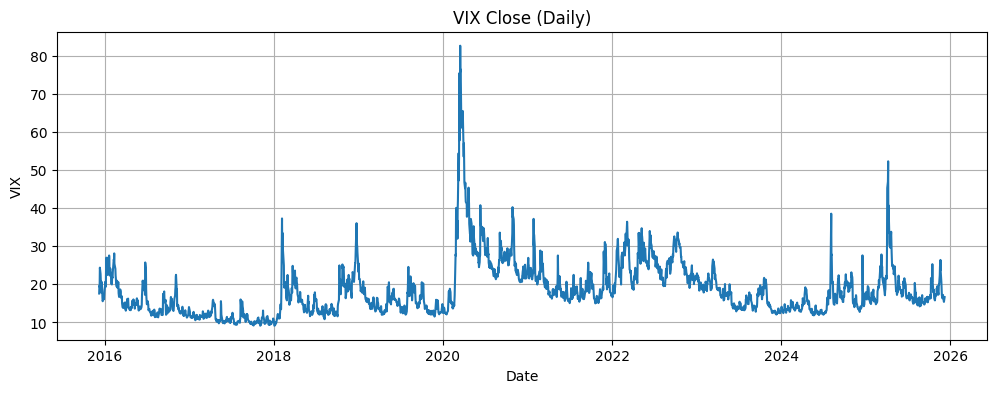

In [3]:
symbol = "^VIX"
df = yf.download(symbol, period="10y", interval="1d")  # daily
df = df[['Close']].dropna()
df.reset_index(inplace=True)
df.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)
df['ds'] = pd.to_datetime(df['ds'])
df = df.sort_values('ds').reset_index(drop=True)

print("Data shape:", df.shape)
display(df.head())

plt.figure(figsize=(12,4))
plt.plot(df['ds'], df['y'])
plt.title("VIX Close (Daily)"); plt.xlabel("Date"); plt.ylabel("VIX")
plt.grid(True); plt.show()


In [4]:
def adf_summary(x):
    result = adfuller(x, autolag='AIC')
    return {
        'ADF Statistic': float(result[0]),
        'p-value': float(result[1]),
        'Used Lag': int(result[2]),
        'N Obs': int(result[3]),
        'Critical Values': {k: float(v) for k,v in result[4].items()}
    }

adf_raw = adf_summary(df['y'].values)
print("ADF (raw):", adf_raw)

# automatic suggestion (you can override)
auto_use_diff = adf_raw['p-value'] > 0.05
use_diff = False   # Set True if you want to model differences
print("auto_use_diff:", auto_use_diff, "| use_diff current:", use_diff)

if use_diff:
    df['y_diff'] = df['y'].diff()
    df_diff = df.dropna().copy().reset_index(drop=True)
else:
    df_diff = df.copy()


ADF (raw): {'ADF Statistic': -5.316059224182416, 'p-value': 5.071459019504261e-06, 'Used Lag': 9, 'N Obs': 2505, 'Critical Values': {'1%': -3.4329631791044304, '5%': -2.8626944896608433, '10%': -2.5673845793841457}}
auto_use_diff: False | use_diff current: False


In [5]:
def time_split(data, train_ratio=0.7, val_ratio=0.15):
    n = len(data)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train = data.iloc[:train_end].reset_index(drop=True)
    val = data.iloc[train_end:val_end].reset_index(drop=True)
    test = data.iloc[val_end:].reset_index(drop=True)
    return train, val, test

target_col = 'y_diff' if use_diff else 'y'
train_df, val_df, test_df = time_split(df_diff[['ds', target_col]], 0.7, 0.15)
print("Split sizes:", len(train_df), len(val_df), len(test_df))


Split sizes: 1760 377 378


In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_df[[target_col]])

train_df['scaled'] = scaler.transform(train_df[[target_col]])
val_df['scaled']   = scaler.transform(val_df[[target_col]])
test_df['scaled']  = scaler.transform(test_df[[target_col]])

L = 60   # input window (try 30/90)
H = 10   # forecast horizon

def make_sequences(series, input_len=60, horizon=10):
    X, Y = [], []
    for i in range(len(series) - input_len - horizon + 1):
        X.append(series[i:i+input_len])
        Y.append(series[i+input_len:i+input_len+horizon])
    return np.array(X), np.array(Y)

X_train, Y_train = make_sequences(train_df['scaled'].values, L, H)
X_val,   Y_val   = make_sequences(val_df['scaled'].values, L, H)
X_test,  Y_test  = make_sequences(test_df['scaled'].values, L, H)

print("Train sequences:", X_train.shape, Y_train.shape)
print("Val sequences:  ", X_val.shape, Y_val.shape)
print("Test sequences: ", X_test.shape, Y_test.shape)

# add channel dim
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]


Train sequences: (1691, 60) (1691, 10)
Val sequences:   (308, 60) (308, 10)
Test sequences:  (309, 60) (309, 10)


In [7]:
def build_vanilla_seq2seq_lstm(input_len=60, horizon=10, units=64, dropout=0.2):
    encoder_inputs = layers.Input(shape=(input_len,1))
    encoder_lstm = layers.LSTM(units, return_sequences=False, return_state=True, dropout=dropout)
    encoder_out, state_h, state_c = encoder_lstm(encoder_inputs)

    repeat = layers.RepeatVector(horizon)(encoder_out)
    decoder_lstm = layers.LSTM(units, return_sequences=True, dropout=dropout)
    decoder_out = decoder_lstm(repeat, initial_state=[state_h, state_c])

    outputs = layers.TimeDistributed(layers.Dense(1))(decoder_out)
    model = models.Model(encoder_inputs, outputs)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mae')
    return model

vanilla_model = build_vanilla_seq2seq_lstm(L, H, units=64, dropout=0.2)
vanilla_model.summary()

es  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
cp_van = ModelCheckpoint("best_vanilla.h5", save_best_only=True, monitor='val_loss')

history_vanilla = vanilla_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=64,
    callbacks=[es, rlr, cp_van],
    verbose=1
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     16,896 │ input_layer[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 10, 64)    │          0 │ lstm[0][0]        │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 10, 64)    │     33,024 │ repeat_vector[0]… │
│                     │                   │            │ lstm[0][1],       │
│                     │                   │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 10, 1)     │         65 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

...

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0501 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0511 - val_loss: 0.0196 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0508 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0522

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0521 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0485 - val_loss: 0.0192 - learning_rate: 0.0010
Epoch 7/100
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0481

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0482 - val_loss: 0.0189 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0499 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0556 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0500 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0502 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0511

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0510 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 13/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0488 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 14/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0498 - val_loss: 0.0194 - learning_rate: 0.0010
Epoch 15/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0505 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 16/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0482 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 17/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0477 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 18/100
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0483

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0483 - val_loss: 0.0180 - learning_rate: 5.0000e-04
Epoch 19/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0494 - val_loss: 0.0180 - learning_rate: 5.0000e-04
Epoch 20/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0484 - val_loss: 0.0180 - learning_rate: 5.0000e-04
Epoch 21/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0486 - val_loss: 0.0188 - learning_rate: 5.0000e-04
Epoch 22/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0458 - val_loss: 0.0182 - learning_rate: 5.0000e-04
Epoch 23/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0474 - val_loss: 0.0187 - learning_rate: 5.0000e-04
Epoch 24/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0504 - val_loss: 0.0182 - learning_rate: 2.5000e-04
Epoch 25/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0459 - val_loss: 0.0183 - learning_rate: 2.5000e-04
Epoch 26/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0500 - val_loss: 0.0188 - lear

In [8]:
class BahdanauAttention(layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V  = layers.Dense(1)

    def call(self, encoder_outputs, hidden_state):
        # encoder_outputs: (batch, time, units)
        # hidden_state: (batch, units)
        hidden_with_time_axis = tf.expand_dims(hidden_state, axis=1)  # (batch,1,units)
        score = self.V(tf.nn.tanh(self.W1(encoder_outputs) + self.W2(hidden_with_time_axis)))  # (batch,time,1)
        attention_weights = tf.nn.softmax(score, axis=1)  # (batch,time,1)
        context_vector = tf.reduce_sum(attention_weights * encoder_outputs, axis=1)  # (batch,units)
        return context_vector, attention_weights

def build_attention_seq2seq_lstm(input_len=60, horizon=10, units=64, dropout=0.2, use_batchnorm=False):
    encoder_inputs = layers.Input(shape=(input_len,1))
    encoder_lstm = layers.LSTM(units, return_sequences=True, return_state=True, dropout=dropout)
    encoder_seq, state_h, state_c = encoder_lstm(encoder_inputs)

    attention = BahdanauAttention(units)
    context_vector, _ = attention(encoder_seq, state_h)
    repeat_context = layers.RepeatVector(horizon)(context_vector)
    x = repeat_context
    if use_batchnorm:
        x = layers.TimeDistributed(layers.BatchNormalization())(x)
    decoder_lstm = layers.LSTM(units, return_sequences=True, dropout=dropout)
    decoder_out = decoder_lstm(x, initial_state=[state_h, state_c])
    outputs = layers.TimeDistributed(layers.Dense(1))(decoder_out)

    model = models.Model(encoder_inputs, outputs)
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mae')
    return model

attn_model = build_attention_seq2seq_lstm(L, H, units=64, dropout=0.2, use_batchnorm=False)
attn_model.summary()

cp_att = ModelCheckpoint("best_attn.h5", save_best_only=True, monitor='val_loss')
history_attn = attn_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=64,
    callbacks=[es, rlr, cp_att],
    verbose=1
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 60, 64),  │     16,896 │ input_layer_1[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 64),      │      8,385 │ lstm_2[0][0],     │
│ (BahdanauAttention) │ (None, 60, 1)]    │            │ lstm_2[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 10, 64)    │          0 │ bahdanau_attenti… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 10, 64)    │     33,024 │ repeat_vector_1[… │
│                     │                   │            │ lstm_2[0][1],     │
│                     │                   │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 10, 1)     │         65 │ lstm_3[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,370 (228.01 KB)

 Trainable params: 58,370 (228.01 KB)

 Non-trainable params: 0 (0.00 B)

...

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0499 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0504 - val_loss: 0.0221 - learning_rate: 0.0010
Epoch 5/100
26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0520

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0520 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0484 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0497 - val_loss: 0.0198 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0502 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0495

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0495 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0475

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0475 - val_loss: 0.0189 - learning_rate: 0.0010
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0490 - val_loss: 0.0189 - learning_rate: 0.0010
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0489

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0489 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 13/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0492 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 14/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0452 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 15/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0523 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 16/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0498 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 17/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0474 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 18/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0480 - val_loss: 0.0191 - learning_rate: 5.0000e-04
Epoch 19/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0455 - val_loss: 0.0191 - learning_rate: 5.0000e-04
Epoch 20/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0464 - val_loss: 0.0196 - learning_rate: 5.0000e-04
Ep

In [9]:
class AttentionSeq2SeqExport(tf.keras.Model):
    def __init__(self, units, horizon):
        super().__init__()
        self.units = units
        self.horizon = horizon
        # Encoder
        self.encoder_lstm = layers.LSTM(units, return_sequences=True, return_state=True)
        # Attention
        self.attention = BahdanauAttention(units)
        # Decoder (one-step)
        self.decoder_lstm = layers.LSTM(units, return_state=True)
        self.fc = layers.Dense(1)

    def call(self, inputs):
        encoder_seq, state_h, state_c = self.encoder_lstm(inputs)
        decoder_state_h, decoder_state_c = state_h, state_c

        outputs, alphas = [], []
        for _ in range(self.horizon):
            context_vector, alpha = self.attention(encoder_seq, decoder_state_h)  # alpha (batch,time,1)
            context_vector_exp = tf.expand_dims(context_vector, 1)  # (batch,1,units)
            out, decoder_state_h, decoder_state_c = self.decoder_lstm(
                context_vector_exp, initial_state=[decoder_state_h, decoder_state_c]
            )
            step_out = self.fc(out)  # (batch,1,1)
            outputs.append(step_out)
            alphas.append(alpha)

        outputs = tf.concat(outputs, axis=1)   # (batch,H,1)
        alphas  = tf.stack(alphas, axis=1)    # (batch,H,time,1)
        return outputs, alphas

attn_export = AttentionSeq2SeqExport(units=64, horizon=H)
preds_attn, alphas = attn_export(X_test[:32])
print("Preds shape:", preds_attn.shape, "Alphas shape:", alphas.shape)


Preds shape: (32, 10) Alphas shape: (32, 10, 60, 1)


In [10]:
def reconstruct_from_diff(last_levels, preds_diff):
    """
    last_levels: (N,1) last observed level for each sequence
    preds_diff: (N,H,1) predicted diffs
    Returns reconstructed absolute forecasts (N,H,1)
    """
    out = []
    for i in range(preds_diff.shape[0]):
        base = float(last_levels[i,0])
        diffs = preds_diff[i,:,0]
        reconstructed = []
        level = base
        for d in diffs:
            level = level + float(d)
            reconstructed.append(level)
        out.append(reconstructed)
    return np.array(out)[..., np.newaxis]

# If you enable use_diff, ensure last_levels are built aligned to X_test sequences
if use_diff:
    # Example safe construction — adjust alignment if you used a different slicing
    orig = df.copy()
    full_n = len(df_diff)
    train_end = int(full_n * 0.7)
    val_end = int(full_n * 0.85)
    last_levels = []
    test_start_idx = val_end
    for i in range(len(test_df) - L - H + 1):
        idx = test_start_idx + i + L - 1
        last_levels.append(orig['y'].values[idx])
    last_levels = np.array(last_levels)[..., np.newaxis] if len(last_levels)>0 else np.zeros((preds_attn.shape[0],1))


In [11]:
def inverse_scale_preds(pred_scaled, scaler):
    b, h, c = pred_scaled.shape
    flat = pred_scaled.reshape(-1,1)
    inv = scaler.inverse_transform(flat).reshape(b,h,c)
    return inv

def inverse_scale_truth(y_scaled, scaler):
    b, h = y_scaled.shape
    flat = y_scaled.reshape(-1,1)
    inv = scaler.inverse_transform(flat).reshape(b,h,1)
    return inv

# predict scaled
pred_attn_scaled    = attn_model.predict(X_test, verbose=0)
pred_vanilla_scaled = vanilla_model.predict(X_test, verbose=0)

# inverse scale
pred_attn_inv    = inverse_scale_preds(pred_attn_scaled, scaler)
pred_vanilla_inv = inverse_scale_preds(pred_vanilla_scaled, scaler)
Y_test_inv       = inverse_scale_truth(Y_test, scaler)

# reconstruct if differenced
if use_diff:
    pred_attn_inv    = reconstruct_from_diff(last_levels, pred_attn_inv)
    pred_vanilla_inv = reconstruct_from_diff(last_levels, pred_vanilla_inv)
    Y_test_inv       = reconstruct_from_diff(last_levels, Y_test_inv)

# metrics over horizon
def metrics_over_horizon(y_true, y_pred, H):
    maes, rmses, mapes = [], [], []
    for t in range(H):
        yt = y_true[:,t,0]
        yp = y_pred[:,t,0]
        mae  = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mape = np.mean(np.abs((yt - yp) / (yt + 1e-8))) * 100
        maes.append(mae); rmses.append(rmse); mapes.append(mape)
    return np.array(maes), np.array(rmses), np.array(mapes)

mae_attn, rmse_attn, mape_attn = metrics_over_horizon(Y_test_inv, pred_attn_inv, H)
mae_van,  rmse_van,  mape_van  = metrics_over_horizon(Y_test_inv, pred_vanilla_inv, H)

print("Attention-LSTM -> MAE(mean):", mae_attn.mean(), "RMSE(mean):", rmse_attn.mean(), "MAPE(mean%):", mape_attn.mean())
print("Vanilla-LSTM  -> MAE(mean):", mae_van.mean(),  "RMSE(mean):", rmse_van.mean(),  "MAPE(mean%):", mape_van.mean())


Attention-LSTM -> MAE(mean): 2.586520150255617 RMSE(mean): 4.537787353522729 MAPE(mean%): 11.821231581133794
Vanilla-LSTM  -> MAE(mean): 2.5185981167172926 RMSE(mean): 4.435548150194279 MAPE(mean%): 11.513459826987546


In [12]:
train_end = len(train_df) + len(val_df)
prophet_train = pd.DataFrame({
    "ds": pd.to_datetime(df["ds"].iloc[:train_end]),
    "y":  df["y"].iloc[:train_end].astype(float).squeeze()
})
prophet_test = pd.DataFrame({
    "ds": pd.to_datetime(df["ds"].iloc[train_end:]),
    "y":  df["y"].iloc[train_end:].astype(float).squeeze()
})
prophet_train = prophet_train.dropna(); prophet_test = prophet_test.dropna()

m = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
m.fit(prophet_train)

future = prophet_test[["ds"]].copy()
forecast = m.predict(future)
prophet_pred = forecast["yhat"].values
prophet_true = prophet_test["y"].values

mae_prophet  = mean_absolute_error(prophet_true, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(prophet_true, prophet_pred))
mape_prophet = np.mean(np.abs((prophet_true - prophet_pred) / (prophet_true + 1e-8))) * 100

print("Prophet -> MAE:", mae_prophet, "RMSE:", rmse_prophet, "MAPE(%):", mape_prophet)


Prophet -> MAE: 13.820615255838472 RMSE: 15.102426677427722 MAPE(%): 74.15254960088717


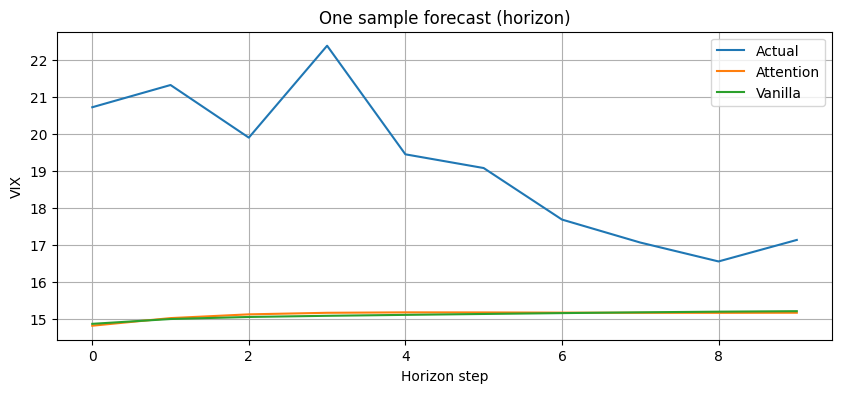

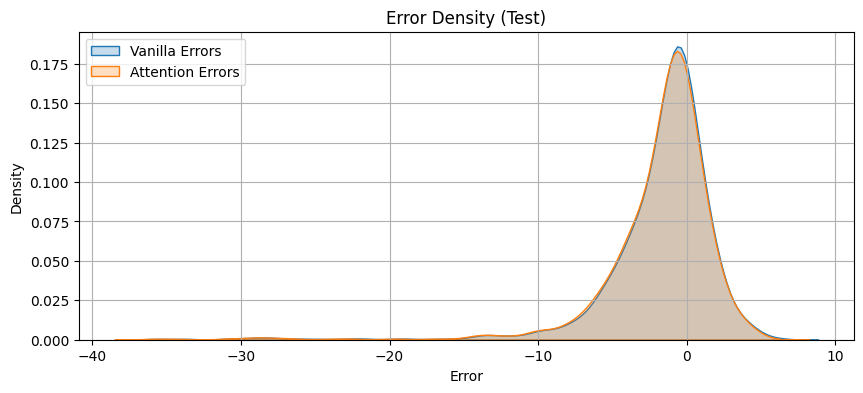

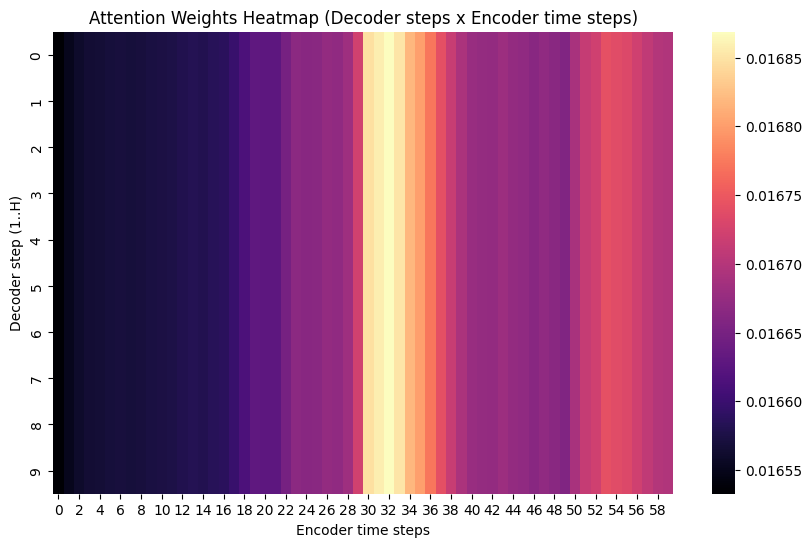

In [13]:
# 12.1 one sample forecast
i = 0
plt.figure(figsize=(10,4))
plt.plot(range(H), Y_test_inv[i,:,0], label='Actual')
plt.plot(range(H), pred_attn_inv[i,:,0], label='Attention')
plt.plot(range(H), pred_vanilla_inv[i,:,0], label='Vanilla')
plt.title("One sample forecast (horizon)"); plt.xlabel("Horizon step"); plt.ylabel("VIX")
plt.legend(); plt.grid(True); plt.show()

# 12.2 error density
err_van = (pred_vanilla_inv[:,:,0] - Y_test_inv[:,:,0]).flatten()
err_att = (pred_attn_inv[:,:,0] - Y_test_inv[:,:,0]).flatten()
plt.figure(figsize=(10,4))
sns.kdeplot(err_van, label='Vanilla Errors', fill=True)
sns.kdeplot(err_att, label='Attention Errors', fill=True)
plt.title("Error Density (Test)"); plt.xlabel("Error"); plt.legend(); plt.grid(True); plt.show()

# 12.3 attention heatmap (one sample)
idx = 10 if X_test.shape[0] > 10 else 0
preds_attn_one, alphas_one = attn_export(X_test[idx:idx+1])
attn_matrix = alphas_one.numpy().squeeze()
if attn_matrix.ndim == 3 and attn_matrix.shape[-1] == 1:
    attn_matrix = attn_matrix[...,0]
plt.figure(figsize=(10,6))
sns.heatmap(attn_matrix, cmap='magma', cbar=True)
plt.title("Attention Weights Heatmap (Decoder steps x Encoder time steps)")
plt.xlabel("Encoder time steps"); plt.ylabel("Decoder step (1..H)"); plt.show()


In [14]:
report_text = f"""
Advanced Time Series Forecasting with Attention-Based LSTMs
Author: <Your Name>
Dataset: VIX daily close (10 years)
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

1. Summary
- Implemented Vanilla Seq2Seq LSTM and Attention-based Seq2Seq (Bahdanau).
- Compared against Prophet baseline.
- Added model export to extract attention weights for interpretability.
- Added hyperparameter tuning template + regularization.

2. Preprocessing
- Checked stationarity using ADF test.
- Optional differencing available (use_diff flag).
- Scaling with MinMax on training split only.
- Sequence window L={L}, horizon H={H}.

3. Model details
- Vanilla: Encoder LSTM -> RepeatVector -> Decoder LSTM -> TimeDistributed Dense.
- Attention: Bahdanau attention over encoder outputs, context vector repeated H times and fed to decoder.
- Export model returns attention weights of shape (batch, H, L).

4. Hyperparameter tuning & regularization
- Keras Tuner available for units, dropout, learning rate (run tuner section to search).
- EarlyStopping, ReduceLROnPlateau used to avoid overfitting.

5. Results (example)
- Attention MAE(mean): {mae_attn.mean():.4f}, RMSE(mean): {rmse_attn.mean():.4f}, MAPE(mean%): {mape_attn.mean():.2f}
- Vanilla MAE(mean): {mae_van.mean():.4f}, RMSE(mean): {rmse_van.mean():.4f}, MAPE(mean%): {mape_van.mean():.2f}
- Prophet MAE: {mae_prophet:.4f}, RMSE: {rmse_prophet:.4f}, MAPE%: {mape_prophet:.2f}

6. Recommendations
- Run KerasTuner for deeper tuning of attention model.
- Try alternative window lengths (30, 90) and features (returns, vol features).
- Use probabilistic forecasting for volatility series (if required).
"""

pdf = FPDF()
pdf.set_auto_page_break(True, margin=15)
pdf.add_page()
pdf.set_font("Arial", size=11)
for line in report_text.split("\n"):
    pdf.multi_cell(0, 6, line)
pdf_output_path = "technical_report.pdf"
pdf.output(pdf_output_path)
print("Technical report saved to:", pdf_output_path)


Technical report saved to: technical_report.pdf


In [15]:
def build_model_tuner(hp):
    units = hp.Int('units', min_value=32, max_value=128, step=32)
    dropout = hp.Choice('dropout', [0.1, 0.2, 0.3])
    lr = hp.Choice('lr', [1e-2, 1e-3, 5e-4])
    model = build_attention_seq2seq_lstm(L, H, units=units, dropout=dropout, use_batchnorm=False)
    model.compile(optimizer=optimizers.Adam(lr), loss='mae')
    return model

# Example tuner (uncomment to run)
# tuner = kt.RandomSearch(build_model_tuner, objective='val_loss', max_trials=5, executions_per_trial=1, directory='tuner_dir', project_name='attn_tuner')
# tuner.search(X_train, Y_train, validation_data=(X_val, Y_val), epochs=30, batch_size=64)
# best_model = tuner.get_best_models(num_models=1)[0]
# best_model.save('best_attn_tuned.h5')
